
# Random Forests y exploración aleatorizada

Definimos primero unas librerías y funciones que vamos a usar a durante la sesión:

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pylab as pl
import pandas as pd
from sklearn.datasets import make_circles
from matplotlib.colors import Normalize
from time import time

In [ ]:
# Función para visualizar un conjunto de datos en 2D
def graficar_datos(X, y):
    y_unico = np.unique(y)  # Identifica los valores únicos en y, que representan las clases
    colores = pl.cm.rainbow(np.linspace(0.0, 1.0, y_unico.size))  # Asigna un color diferente para cada clase

    for this_y, color in zip(y_unico, colores):  # Itera sobre cada clase y color asignado
        this_X = X[y == this_y]  # Filtra los datos de la clase actual
        pl.scatter(this_X[:, 0], this_X[:, 1], c=color,  # Grafica los datos de la clase con su color
                   alpha=0.5, edgecolor='k',  # Transparencia de los puntos y borde negro
                   label="Class %s" % this_y)  # Etiqueta para la leyenda de cada clase

    pl.legend(loc="best")  # Muestra la leyenda de las clases
    pl.title("Data")  # Título del gráfico


# Función para visualizar de la superficie de decisión de un clasificador
def plot_decision_region(X, pred_fun):
    min_x = np.min(X[:, 0])  # Encuentra el valor mínimo de la primera característica
    max_x = np.max(X[:, 0])  # Encuentra el valor máximo de la primera característica
    min_y = np.min(X[:, 1])  # Encuentra el valor mínimo de la segunda característica
    max_y = np.max(X[:, 1])  # Encuentra el valor máximo de la segunda característica

    # Ajusta el rango de los ejes con un 5% de margen adicional para mejorar la visualización
    min_x = min_x - (max_x - min_x) * 0.05
    max_x = max_x + (max_x - min_x) * 0.05
    min_y = min_y - (max_y - min_y) * 0.05
    max_y = max_y + (max_y - min_y) * 0.05

    # Crea una malla de valores en el rango de X e Y
    x_vals = np.linspace(min_x, max_x, 100)
    y_vals = np.linspace(min_y, max_y, 100)
    XX, YY = np.meshgrid(x_vals, y_vals)  # Malla de valores para evaluar el clasificador

    # Crea una matriz ZZ donde cada posición contiene la predicción del clasificador para el punto (x, y)
    grid_r, grid_c = XX.shape
    ZZ = np.zeros((grid_r, grid_c))  # Matriz de predicciones
    for i in range(grid_r):
        for j in range(grid_c):
            ZZ[i, j] = pred_fun(XX[i, j], YY[i, j])  # Llama a la función pred_fun para predicción en cada punto

    # Grafica las regiones de decisión con un mapa de colores y una barra de color
    pl.contourf(XX, YY, ZZ, 100, cmap=pl.cm.coolwarm, vmin=-1, vmax=2)
    pl.colorbar()  # Añade barra de color
    pl.xlabel("x")  # Etiqueta del eje X
    pl.ylabel("y")  # Etiqueta del eje Y


In [ ]:
class MidpointNormalize(Normalize):

    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))

def gen_pred_fun(clf):
    def pred_fun(x1, x2):
        x = np.array([[x1, x2]])
        return clf.predict(x)[0]
    return pred_fun

def plot_labels(n_folds, n_classes, list_labels):
    ind = np.arange(n_folds)
    width = 0.15

    countings = []
    for labels in list_labels:
        labels = np.array(labels)
        countings.append([np.count_nonzero(labels == x) for x in range(n_classes)])

    class_bars = []
    for cls in range(n_classes):
        class_bars.append([l[cls] for l in countings])

    fig, ax = pl.subplots()
    i = 0
    for class_bar in class_bars:
        ax.bar(ind + width*i, class_bar, width, label='Clase '+str(i))
        i += 1

    ax.set_xticks(ind + 2*width / 3)
    ax.set_xticklabels(['Pliegue {}'.format(k) for k in range(n_folds)])
    pl.legend(loc="best")
    pl.title("Etiquetas")

# Árboles de decisión y Bagging (Bootstrap Aggregating)

Considere el siguiente conjunto de datos

In [ ]:
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split

np.random.seed(0)  # Fija la semilla para asegurar la reproducibilidad

# Genera un conjunto de datos con forma de círculos:
X, y = make_circles(n_samples=1000,  # Genera 1000 muestras
                    factor=.4,       # Define el tamaño relativo del círculo interior al exterior
                    noise=.15)       # Agrega ruido gaussiano a los puntos

# Divide el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Conjunto de datos de características
    y,                 # Etiquetas correspondientes
    test_size=0.4,     # Proporción de datos para el conjunto de prueba (40%)
    random_state=2)    # Fija la semilla para reproducibilidad


/tmp/ipython-input-3855094893.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  pl.scatter(this_X[:, 0], this_X[:, 1], c=color,  # Grafica los datos de la clase con su color


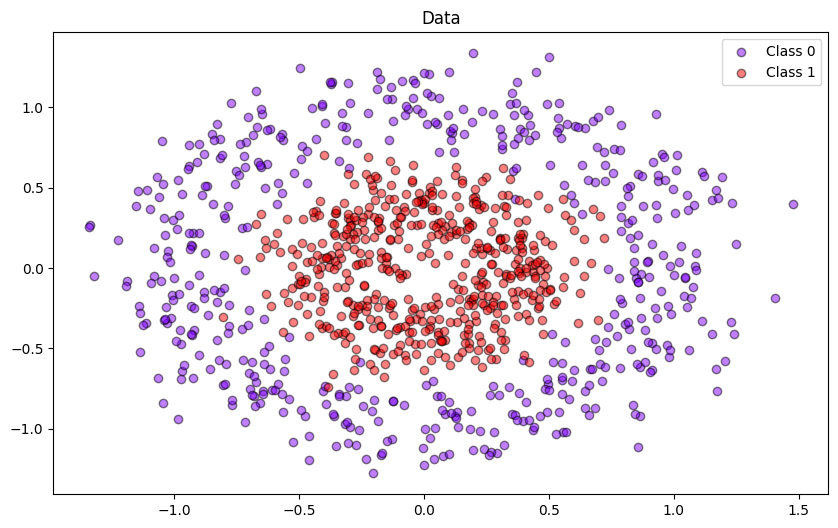

In [ ]:
pl.figure(figsize = (10, 6))
graficar_datos(X, y)

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

Entrenar un modelo de árbol de decisión para resolver este problema de clasificación.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Entrenamos un árbol de decisión de profundidad máxima 5
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

Error en entrenamiento: 0.021666666666666612
Error en prueba: 0.06000000000000005


/tmp/ipython-input-3855094893.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  pl.scatter(this_X[:, 0], this_X[:, 1], c=color,  # Grafica los datos de la clase con su color


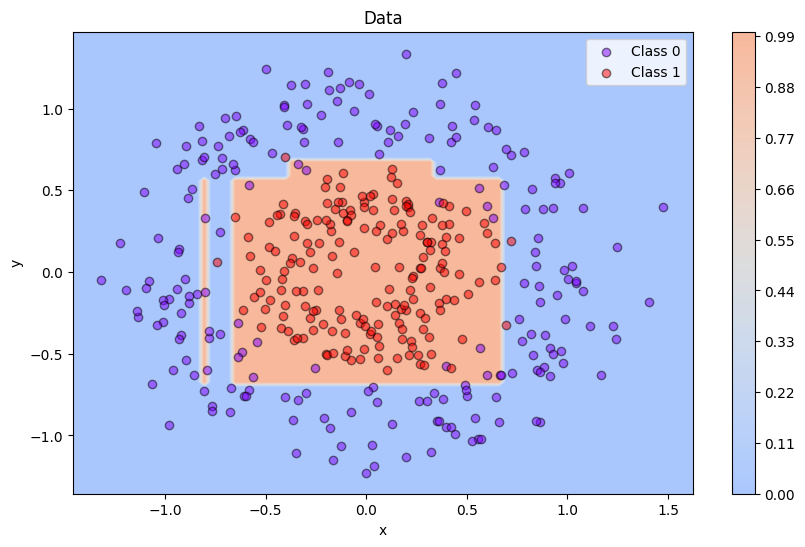

In [ ]:
print('Error en entrenamiento: {}'.format(1-dt.score(X_train, y_train)))
print('Error en prueba: {}'.format(1-dt.score(X_test, y_test)))

pl.figure(figsize = (10, 6))
plot_decision_region(X_test, gen_pred_fun(dt))
graficar_datos(X_test, y_test)

El modelo presenta un error de generalización del $6\%$, además sus predicciones no se ajustan a la naturaleza de los datos

Problemas:
* En algunos casos, las franteras de decisión generadas por el árbol de decisión (paralelas a los ejes) no son lo suficientemente flexibles para capturar la no linealidad del conjunto de datos.
* Por otro lado, los árboles de decisión pueden crear reglas de decisión muy específicas que se ajustan demasiado a los datos de entrenamiento.
* Tambien son sensibles a pequeñas variaciones de los datos que pueden resultar en árboles totalmente distintos. Esto es un problema cuando se hace validación cruzada de k-pliegues.

**¿Cómo abordar este problema?**

utilizar una estrategia conocida como *clasificación por comité* o *ensamble de clasificadores*. Un ensamble de clasificadores combina diferentes algoritmos de aprendizaje para obtener un mejor desempeño predictivo. A continuación, presentamos una forma de cómo construír un ensamble de árboles de clasificación. Se entrenan diferentes árboles en diferentes subconjuntos de los datos de entrenamiento. Posteriormente cuando se va hacer una predicción para un nuevo dato, se obtienen las predicciones de todos los árboles y se regresa aquella clase de mayor frecuencia predicha.

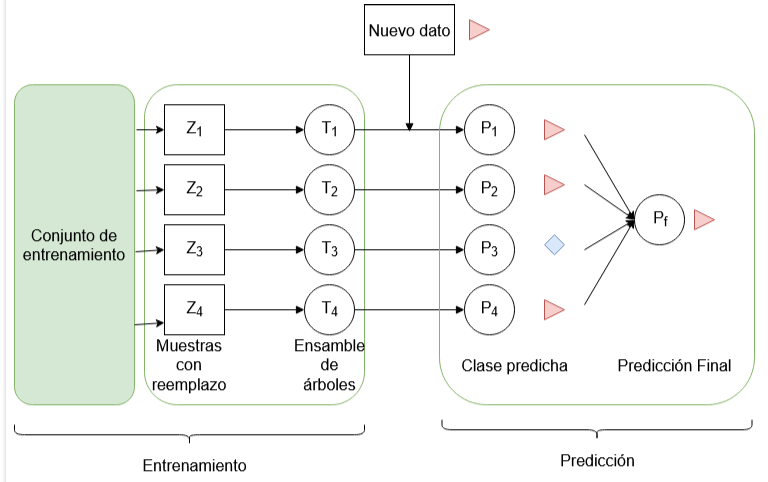


A la técnica de la figura se le conoce como *bagging*. En el ejemplo siguiente vamos a utilizar la función `BaggingClassifier` la cual entrena un modelo usando esta estrategia. Los parámetros recibidos por la función son los siguientes:
*  `estimator`: Consiste en el estimador base que se va a entrenar sobre los diferentes subconjuntos del conjunto de datos de entrenamiento.
* `n_estimators`: Es el número de estimadores base que se van a usar para la estrategia de *bagging*.

Error en entrenamiento: 0.011666666666666714
Error en prueba: 0.050000000000000044


/tmp/ipython-input-3855094893.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  pl.scatter(this_X[:, 0], this_X[:, 1], c=color,  # Grafica los datos de la clase con su color


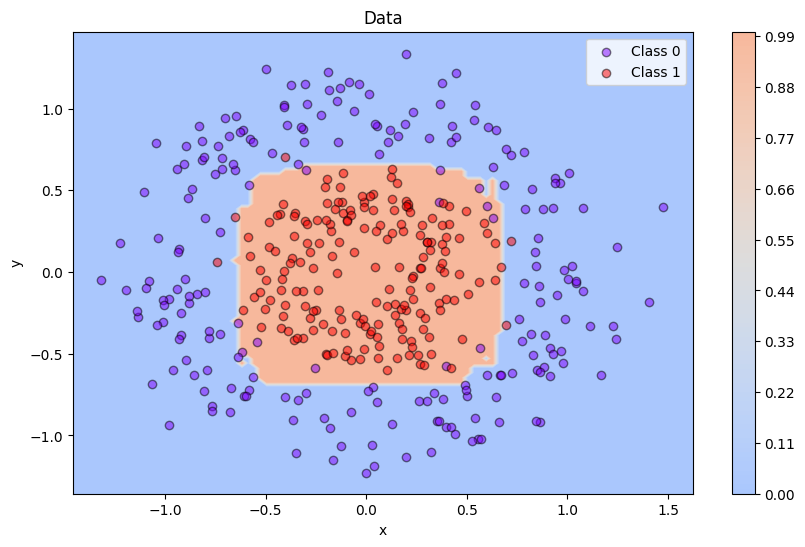

In [ ]:
from sklearn.ensemble import BaggingClassifier
# https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.BaggingClassifier.html

# Crea un clasificador de tipo Bagging usando árboles de decisión con una profundidad máxima de 5 y 40 estimadores (árboles)
bc = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5), n_estimators=40)

# Ajusta el clasificador a los datos de entrenamiento
bc.fit(X_train, y_train)

# Calcula y muestra el error en el conjunto de entrenamiento
print('Error en entrenamiento: {}'.format(1 - bc.score(X_train, y_train)))

# Calcula y muestra el error en el conjunto de prueba
print('Error en prueba: {}'.format(1 - bc.score(X_test, y_test)))

# Configura una figura para la visualización de la superficie de decisión
pl.figure(figsize=(10, 6))

# Llama a la función `plot_decision_region` para graficar la superficie de decisión del modelo entrenado
plot_decision_region(X_test, gen_pred_fun(bc))

# Llama a `graficar_datos` para mostrar los puntos de datos de prueba en el gráfico
graficar_datos(X_test, y_test)


# Random Forests

Existen varias alternativas para combinar y promediar árboles de decisión, una de las más usadas es Random Forest. Scikit-Learn provee una implementación a través de `sklearn.ensemble.RandomForestClassifier`. Más adelante se discuten los parámetros más importantes de esta implementación.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=20, max_depth=5)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=20)

/tmp/ipython-input-3855094893.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  pl.scatter(this_X[:, 0], this_X[:, 1], c=color,  # Grafica los datos de la clase con su color


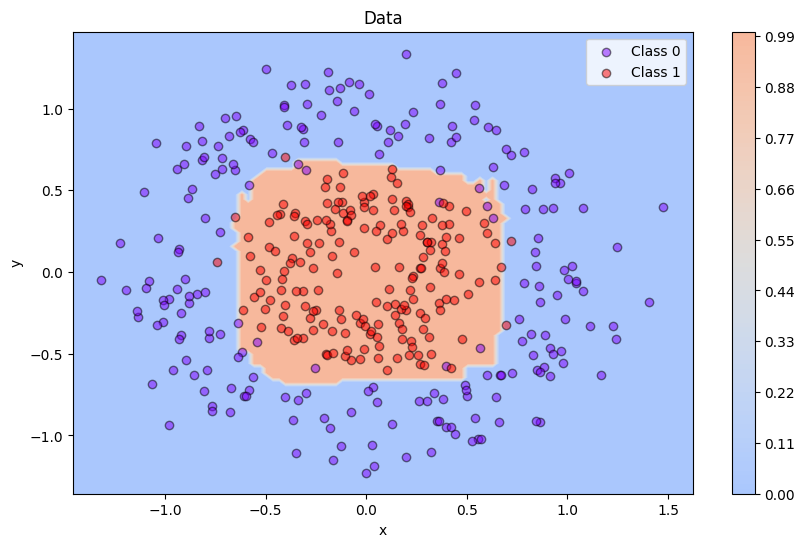

In [ ]:
pl.figure(figsize = (10, 6))
plot_decision_region(X_test, gen_pred_fun(rf))
graficar_datos(X_test, y_test)

In [ ]:
print('Error en entrenamiento: {}'.format(1-rf.score(X_train, y_train)))
print('Error en prueba: {}'.format(1-rf.score(X_test, y_test)))

Error en entrenamiento: 0.013333333333333308
Error en prueba: 0.040000000000000036


Mientras baja el error de generalización, observamos tambien que se adapta mejor a la naturaleza de los datos

## Intuición detrás de RandomForests

Random Forest es una técnica de **ensamble** que combina diferentes árboles de decisión. Estos árboles se entrenan en diferentes muestras del conjunto de datos, estos árboles pueden sobreajustarse, sin embargo la combinación de sus predicciones resulta en un clasificador con menor sobreajuste. Para entender la idea de cómo se construye este algoritmo, suponga que entrenamos los siguientes árboles para determinar si una persona está enferma o sana:

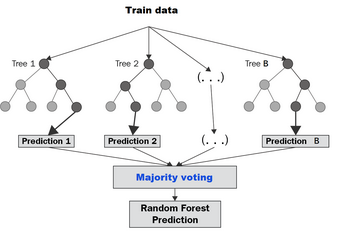

## ¿Qué sucede si todos los árboles de clasificación son iguales?

## ¿Cómo logro que cada árbol de clasificación sea diferente?

## Algoritmo básico Random Forest

A diferencia del árbol común de decisión, los árboles de Random Forest se entrenan de una forma diferente. A continuación, presentamos el algoritmo básico de entrenamiento:

1. Para cada árbol se realiza el siguiente procedimiento:
    * Se escoge una muestra con reemplazo de tamaño $n$ del conjunto de entrenamiento.
    * Se seleccionan $m$ variables al azar de las variables disponibles
    * Se entrena un árbol sobre la muestra usando las $m$ variables repitiendo los siguientes pasos:
        * Se escoge la variable (y umbral) que genera la mejor partición
        * Se divide los datos en dos subconjuntos de acuerdo a la variable y el umbral
        * Si no se satisface un criterio de parada se aplica este procedimiento recursivamente sobre los subconjutos
2. Una vez cada árbol ha sido entrenado, se genera el ensamble de árboles.

## Implementación en Scikit-Learn

La implementación en Scikit-Learn nos permite controlar los siguientes parámetros:
* `n_estimators`: Número de árboles a entrenar
* `max_features`: Número de variables $m$ al azar que se tienen en cuenta para la construcción de cada árbol.

Un número grande de árboles resulta en un buen desempeño a costas del costo computacional. Ambos parámetros deben ser explorados usando validación cruzada. A continuación, usaremos el conjunto de datos `wine`.

In [ ]:
pip install ucimlrepo

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

# Cargar el conjunto de datos de ejemplo de sklearn
wine_data = load_wine()

# Convertir los datos a un DataFrame
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Agregar la columna de etiquetas de clase (el tipo de vino)
df['target'] = wine_data.target

df.head()
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


Generamos la matriz de características y el arreglo de etiquetas

In [ ]:
X = df.drop(columns=['target'], axis=1).values
y = df['target'].values
print(X.shape)
print(y.shape)

(178, 13)
(178,)


# Técnica de ajustes de hiperparámetros de los modelos, aplicado a bosques aleatorios.

**Ajuste exhaustivo de hiperparámetros (GridSearch)**

Definimos la malla de parámetros:

GridSearchCV es una herramienta en la biblioteca scikit-learn que se utiliza para realizar búsqueda de hiperparámetros en un modelo de aprendizaje automático. La "búsqueda en cuadrícula" (GridSearch) implica probar exhaustivamente todas las combinaciones posibles de un conjunto de hiperparámetros especificados, y el "CV" se refiere a la validación cruzada (cross-validation) que se aplica durante esta búsqueda.

In [ ]:
# Lista de valores para el parámetro 'max_features'
max_features_params = np.linspace(0.1, 1.0, 10).tolist()

# define todas las combinaciones posibles de valores de n_estimators y max_features
#para realizar una búsqueda de hiperparámetros y optimizar el modelo.
# Definición del diccionario de parámetros 'param_grid'
param_grid = {
    'n_estimators': [2**i for i in range(2, 12, 1)],  # Lista de valores de n_estimators
    'max_features': max_features_params               # Lista de valores de max_features
}


In [ ]:
print('Número de árboles: {}'.format(param_grid['n_estimators']))

Número de árboles: [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]


In [ ]:
print('Porcentaje de características a usar: {}'.format(param_grid['max_features']))

Porcentaje de características a usar: [0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7000000000000001, 0.8, 0.9, 1.0]


Crear la partición de entrenamiento y prueba

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

Corremos el modelo `GridSearchCV` usando la malla de parámetros

In [ ]:
# Realiza una búsqueda de hiperparámetros usando GridSearchCV en un modelo RandomForestClassifier,
# y mide cuánto tiempo tomó completar la búsqueda

start = time()  # Registra el tiempo inicial para calcular el tiempo total al final

# Configura GridSearchCV con RandomForestClassifier y el conjunto de parámetros definidos en 'param_grid'
clf = GridSearchCV(
    RandomForestClassifier(),  # Modelo a optimizar
    param_grid=param_grid,     # Cuadrícula de hiperparámetros a explorar
    verbose=1,                 # Nivel de verbosidad para mostrar el progreso en consola
    n_jobs=-1,                 # Utiliza todos los núcleos de CPU disponibles para acelerar la búsqueda
    cv=5                       # Realiza validación cruzada con 5 particiones
)

# Ajusta el modelo en los datos de entrenamiento utilizando todas las combinaciones de hiperparámetros
clf.fit(X_train, y_train)

# Muestra el tiempo total y el número de configuraciones probadas
print("GridSearchCV tomó {} segundos usando {} configuraciones".format(
    time() - start,                        # Tiempo total transcurrido
    len(clf.cv_results_['params'])         # Número de configuraciones evaluadas
))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
GridSearchCV tomó 324.2231955528259 segundos usando 100 configuraciones


Usando `cv_results_` extraemos el desempeño promedio sobre cada configuración de parámetros

In [ ]:
scores = clf.cv_results_['mean_test_score'].reshape(len(param_grid['max_features']),
                                                    len(param_grid['n_estimators']))

In [ ]:
scores

array([[0.94333333, 0.96      , 0.968     , 0.984     , 0.984     ,
        0.984     , 0.984     , 0.984     , 0.984     , 0.984     ],
       [0.91966667, 0.976     , 0.984     , 0.984     , 0.984     ,
        0.984     , 0.984     , 0.984     , 0.984     , 0.984     ],
       [0.92733333, 0.97566667, 0.976     , 0.984     , 0.97566667,
        0.97566667, 0.97566667, 0.97566667, 0.97566667, 0.97566667],
       [0.944     , 0.95166667, 0.97566667, 0.97566667, 0.97566667,
        0.97566667, 0.97566667, 0.97566667, 0.97566667, 0.97566667],
       [0.93566667, 0.96766667, 0.95966667, 0.97566667, 0.96733333,
        0.96766667, 0.97566667, 0.97566667, 0.97566667, 0.97566667],
       [0.935     , 0.95166667, 0.95966667, 0.96733333, 0.97566667,
        0.97566667, 0.97566667, 0.97566667, 0.97566667, 0.97566667],
       [0.95966667, 0.96766667, 0.94333333, 0.95966667, 0.97566667,
        0.97566667, 0.96766667, 0.97566667, 0.97566667, 0.97566667],
       [0.90366667, 0.92766667, 0.9433333

Visualizamos la mejor combinación de parámetros:

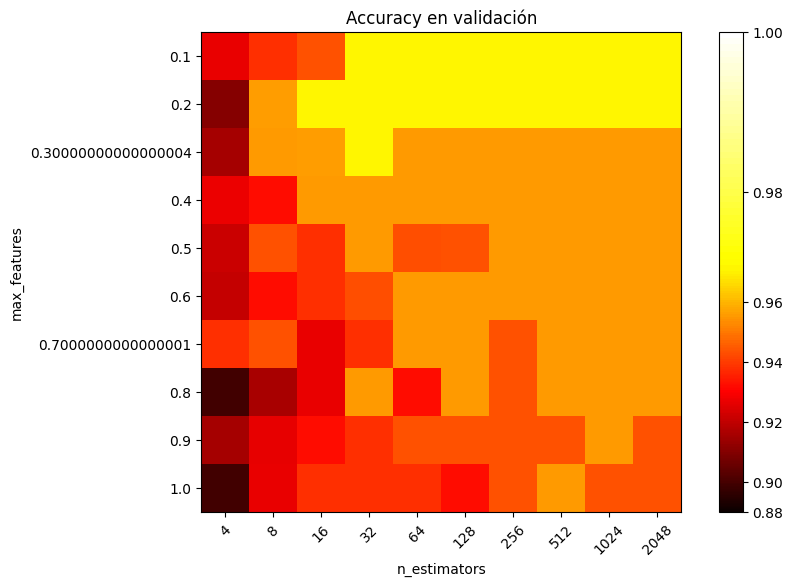

In [ ]:
# Configura la figura y el tamaño de la imagen
pl.figure(figsize=(10, 6))

# Ajusta los márgenes de la subparcela para mejorar la visualización
pl.subplots_adjust(left=0.2, right=0.95, bottom=0.15, top=0.95)

# Muestra el mapa de calor de los puntajes de precisión
pl.imshow(scores, interpolation='nearest', cmap=plt.cm.hot,
           norm=MidpointNormalize(vmin=0.89, midpoint=0.97, vmax=1.))

pl.xlabel('n_estimators')
pl.ylabel('max_features')
pl.colorbar()
pl.xticks(np.arange(len(param_grid['n_estimators'])), param_grid['n_estimators'], rotation=45)
pl.yticks(np.arange(len(param_grid['max_features'])), param_grid['max_features'])
pl.title('Accuracy en validación')
pl.show()

La mejor combinación de parámetros está dada por:

In [ ]:
clf.best_params_

{'max_features': 0.1, 'n_estimators': 32}

In [ ]:
clf.best_score_

np.float64(0.984)

Finalmente, reportamos en el conjunto de prueba:

In [ ]:
clf.score(X_test, y_test)

1.0

Importancia de características

Una ventaja muy significativa de usar Random Forests consiste en la posibilidad de obtener la importancia de las características del conjunto de datos. Esta importancia nos indica qué tanto una característica contribuye al desempeño en los nodos de los diferentes árboles.

A continuación, seguimos usando el conjunto de datos `wine` y obtenemos la importancia de las características del mejor modelo usando validación cruzada. Entrenemos de nuevo el modelo:

In [ ]:
clf = RandomForestClassifier(n_estimators=32, max_features=.1)

clf.fit(X_train, y_train);

Extraemos la importancia de las características

In [ ]:
clf.feature_importances_

array([0.13711085, 0.06185875, 0.04075703, 0.06987906, 0.04718554,
       0.0601715 , 0.05351816, 0.04191565, 0.06909971, 0.11886417,
       0.0871432 , 0.09886741, 0.11362897])

A continuación ordenamos las características por su importancia

In [ ]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Importancia de características:")

for f in range(X_train.shape[1]):
    print("Característica %s (%f)" % (df.columns[int(1+indices[f])], importances[indices[f]]))

Importancia de características:
Característica malic_acid (0.137111)
Característica hue (0.118864)
Característica target (0.113629)
Característica proline (0.098867)
Característica od280/od315_of_diluted_wines (0.087143)
Característica magnesium (0.069879)
Característica color_intensity (0.069100)
Característica ash (0.061859)
Característica flavanoids (0.060171)
Característica nonflavanoid_phenols (0.053518)
Característica total_phenols (0.047186)
Característica proanthocyanins (0.041916)
Característica alcalinity_of_ash (0.040757)


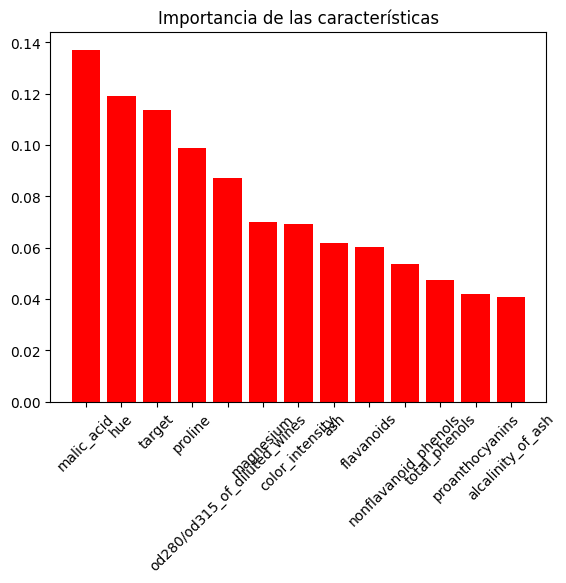

In [ ]:
plt.figure()
plt.title("Importancia de las características")
plt.bar(range(X_train.shape[1]), importances[indices],
       color="r", align="center")
xticks_labels = [df.columns[1+i] for i in indices]
plt.xticks(range(X.shape[1]), xticks_labels, rotation=45)
plt.xlim([-1, X.shape[1]])
plt.show()

**Optimización aleatoria de hiperparámetros**

A pesar de las ventajas que ofrece `GridSearchCV` sobre la exploración sistemática de los hiperparámetros de un modelo, puede gastar un tiempo considerable en esta exploración. Scikit-Learn permite hacer también una exploración aleatoria de los parámetros, la cual se ha demostrado empiricamente que es más eficiente que optimizar los parámetros usando una malla con `GridSearchCV` ([Referencia](http://www.jmlr.org/papers/volume13/bergstra12a/bergstra12a.pdf)). `RandomizedSearchCV` implementa una búsqueda aleatoria sobre los parámetros. El rango de exploración de los parámetros se puede especificar de la siguiente manera:

* Usando una lista:
    * `"criterion": ["gini", "entropy"]`
* Usando una distribución discreta uniforme:
    * `"n_estimators": randint(4, 2048)`
    * `randint` proviene de `scipy.stats`. Este genera una distribución discreta entre 4 y 2048.
* Usando una distribución uniforme:
    * `"max_features": uniform()`
    * `uniform` proviene de `scipy.stats`. Este genera una distribución uniforme entre 0 y 1.
    
`RandomizedSearchCV` puede recibir tanto listas de elementos como distribuciones de probabilidad, las cuales deben ser especificadas usando `scipy.stats`. A continuación, creamos nuestro estimador y definimos la distribución de parámetros:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Modelo a optimizar
clf = RandomForestClassifier()

# Espacio de hiperparámetros aleatorios
param_dist = {"n_estimators": randint(4, 800),
              "max_features": uniform()}

# Configuración de RandomizedSearchCV
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=50, cv=5, random_state=42, n_jobs=-1)

# Ajuste en los datos de entrenamiento
random_search.fit(X_train, y_train)

# Mostrar los mejores parámetros encontrados
print("Mejores hiperparámetros:", random_search.best_params_)


Mejores hiperparámetros: {'max_features': np.float64(0.15599452033620265), 'n_estimators': 334}


In [ ]:
# Convierte los resultados de la búsqueda aleatoria (RandomizedSearchCV) en un DataFrame de Pandas
cv_results = pd.DataFrame(random_search.cv_results_)

# Filtra el DataFrame para incluir solo las columnas de interés: 'param_n_estimators', 'param_max_features', y 'mean_test_score'
cv_results = cv_results[['param_n_estimators', 'param_max_features', 'mean_test_score']]

# Ordena el DataFrame en orden descendente de 'mean_test_score' para obtener los mejores resultados
cv_results.sort_values(by='mean_test_score', ascending=False).head()

,param_n_estimators,param_max_features,mean_test_score
9,280,0.181825,0.984
3,334,0.155995,0.984
16,566,0.090606,0.984
12,478,0.023062,0.984
14,703,0.046666,0.984


In [ ]:
# Mostrar los mejores hiperparámetros según RandomizedSearchCV
print("Mejores hiperparámetros según RandomizedSearchCV:", random_search.best_params_)

# Verificar si coinciden con el mejor resultado en el DataFrame
print("Mejor resultado en cv_results:")
print(cv_results.sort_values(by='mean_test_score', ascending=False).head(1))


Mejores hiperparámetros según RandomizedSearchCV: {'max_features': np.float64(0.15599452033620265), 'n_estimators': 334}
Mejor resultado en cv_results:
   param_n_estimators  param_max_features  mean_test_score
9                 280            0.181825            0.984


In [ ]:
random_search.best_score_

np.float64(0.984)

In [ ]:
random_search.score(X_test, y_test)

1.0

`n_iter_search` nos define el número de configuraciones que vamos a extraer de la distribución de parámetros.

In [ ]:
n_iter_search = 20
random_search2 = RandomizedSearchCV(clf, param_distributions=param_dist,
                                   n_iter=n_iter_search, cv=5,
                                   n_jobs=-1, verbose=2)

In [ ]:
# Inicia el contador de tiempo para medir cuánto tarda la búsqueda aleatoria de hiperparámetros
start = time()

# Realiza la búsqueda aleatoria de hiperparámetros en el modelo usando los datos de entrenamiento
random_search2.fit(X_train, y_train)

# Imprime el tiempo total que tomó completar la búsqueda, indicando el número de configuraciones probadas
print("RandomizedSearchCV tomó {} segundos usando {} configuraciones".format(time() - start, n_iter_search))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV tomó 59.49340057373047 segundos usando 20 configuraciones


In [ ]:
# Mostrar los mejores parámetros encontrados
print("Mejores hiperparámetros:", random_search2.best_params_)

Mejores hiperparámetros: {'max_features': np.float64(0.13253097749036336), 'n_estimators': 549}


`RandomizedSearchCV` también soporta la ejecución en paralelo usando `n_jobs=-1`. También podemos especificar el número de pliegues a usar usando `cv=5`

Extraemos los resultados con mejor desempeño promedio:

In [ ]:
# Convierte los resultados de la búsqueda aleatoria (RandomizedSearchCV) en un DataFrame de Pandas
cv_results2 = pd.DataFrame(random_search2.cv_results_)

# Filtra el DataFrame para incluir solo las columnas de interés: 'param_n_estimators', 'param_max_features', y 'mean_test_score'
cv_results2 = cv_results2[['param_n_estimators', 'param_max_features', 'mean_test_score']]

# Ordena el DataFrame en orden descendente de 'mean_test_score' para obtener los mejores resultados
cv_results2.sort_values(by='mean_test_score', ascending=False).head()



,param_n_estimators,param_max_features,mean_test_score
12,361,0.186093,0.984000
11,378,0.003026,0.984000
6,345,0.219889,0.984000
5,549,0.132531,0.984000
16,778,0.616501,0.975667


Verificamos la mejor configuración y su puntaje sobre todas las particiones de validación:

In [ ]:
random_search2.best_score_

np.float64(0.984)

Reportamos el score de generalización:

In [ ]:
random_search2.score(X_test, y_test)

1.0